In [1]:
!pip install librosa tensorflow scikit-learn matplotlib seaborn gradio kaggle


In [2]:
import os
import librosa
import numpy as np
import hashlib
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
)
from tensorflow.keras.utils import to_categorical


In [3]:
from google.colab import files
files.upload()
!rm -rf ~/.kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [4]:
!kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification -p /content --unzip
!ls /content/Data/genres_original

Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
License(s): other
 98% 1.19G/1.21G [00:18<00:00, 83.0MB/s]
100% 1.21G/1.21G [00:18<00:00, 71.4MB/s]
blues  classical  country  disco  hiphop  jazz	metal  pop  reggae  rock


In [5]:
from sklearn.model_selection import train_test_split
import os
import shutil

dataset_path = "/content/Data/genres_original"

# Collect original audio paths
X_files = []
y_labels = []

for genre in os.listdir(dataset_path):
    genre_path = os.path.join(dataset_path, genre)
    for file in os.listdir(genre_path):
        if file.endswith(".wav"):
            X_files.append(os.path.join(genre_path, file))
            y_labels.append(genre)

# Same split logic as training
X_train_f, X_temp_f, y_train_f, y_temp_f = train_test_split(
    X_files, y_labels,
    test_size=0.3,
    random_state=42,
    stratify=y_labels
)

X_val_f, X_test_f, y_val_f, y_test_f = train_test_split(
    X_temp_f, y_temp_f,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_f
)

print("Total test files:", len(X_test_f))


Total test files: 150


In [6]:
SAMPLE_RATE = 22050

SEGMENT_DURATION = 3    # ✅ split each 30s song into 3s segments
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048

# Frames for 3 seconds of audio
MAX_FRAMES = 130        # ≈ (3 * 22050) / 512


In [7]:
def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

X_files = []
y_labels = []
seen = set()

dataset_path = "/content/Data/genres_original"

for genre in os.listdir(dataset_path):
    genre_path = os.path.join(dataset_path, genre)
    for file in os.listdir(genre_path):
        file_path = os.path.join(genre_path, file)
        h = file_hash(file_path)
        if h not in seen:
            seen.add(h)
            X_files.append(file_path)
            y_labels.append(genre)


In [8]:
def extract_mel_segments(file_path, segments=10):
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    segment_len = int(SEGMENT_DURATION * sr)

    mel_segments = []

    for i in range(segments):
        start = i * segment_len
        end = start + segment_len

        if end > len(audio):
            break

        segment = audio[start:end]

        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=N_MELS,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        mel_db = librosa.util.fix_length(
            mel_db, size=MAX_FRAMES, axis=1
        )

        mel_segments.append(mel_db)

    return mel_segments


In [9]:
X = []
y = []

for path, label in zip(X_files, y_labels):
    try:
        mel_segments = extract_mel_segments(path)  # 👈 segmentation

        for mel in mel_segments:
            X.append(mel)
            y.append(label)

    except Exception as e:
        continue

X = np.stack(X)
y = np.array(y)

print("Final dataset shape:", X.shape, y.shape)


/tmp/ipython-input-475266363.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Final dataset shape: (9841, 128, 130) (9841,)


In [10]:

X = X.astype(np.float32)
mean = np.mean(X)
std = np.std(X)
X = (X - mean) / (std + 1e-8)

print("After normalization:")
print("Mean:", X.mean())
print("Std:", X.std())


After normalization:
Mean: 3.6525264e-06
Std: 0.9999994


In [11]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)


In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.3, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Add channel dimension
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]


In [13]:
model = Sequential([

    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu',
           input_shape=X_train.shape[1:]),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 4
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0003
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,586,890 (17.50 MB)

 Trainable params: 4,585,930 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)


In [16]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)


Epoch 1/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - accuracy: 0.3695 - loss: 2.2757 - val_accuracy: 0.1917 - val_loss: 12.2088 - learning_rate: 3.0000e-04
Epoch 2/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5553 - loss: 1.2605 - val_accuracy: 0.3347 - val_loss: 2.8664 - learning_rate: 3.0000e-04
Epoch 3/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6521 - loss: 0.9922 - val_accuracy: 0.7141 - val_loss: 0.8778 - learning_rate: 3.0000e-04
Epoch 4/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7297 - loss: 0.7812 - val_accuracy: 0.7947 - val_loss: 0.6349 - learning_rate: 3.0000e-04
Epoch 5/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7963 - loss: 0.5744 - val_accuracy: 0.7710 - val_loss: 0.7161 - learning_rate: 3.0000e-04
Epoch 6/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8367 - loss: 0.4694 - val_accuracy: 0.8299 - val_loss: 0.5075 - learning_rate: 3.0000e-04
Epoch 7/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - a

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8647 - loss: 0.5078
Test Accuracy: 0.8747460842132568


In [18]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
[[137   1   2   1   0   5   2   0   1   1]
 [  0 149   0   0   1   0   0   0   0   2]
 [  1   2 134   3   0   3   0   4   4   2]
 [  0   0   4 130   4   0   1   7   1   7]
 [  2   0   1   1 130   0  11   3   1   1]
 [  3   6   0   0   0 143   0   0   0   2]
 [  0   0   0   0   0   0 127   0   0   2]
 [  0   0   1   2   2   0   0 136   5   1]
 [  2   0   2   6   7   0   0   8 113   0]
 [  5   1  12  12   4   5  11   5   2  93]]


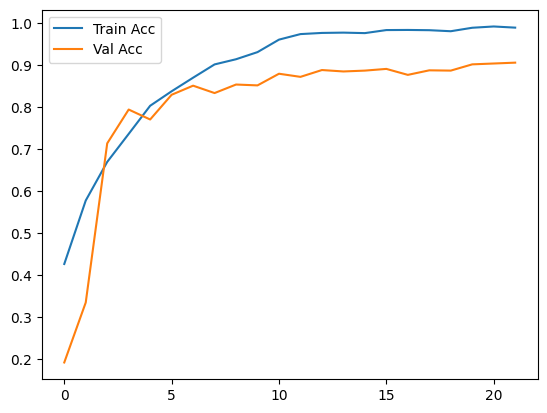

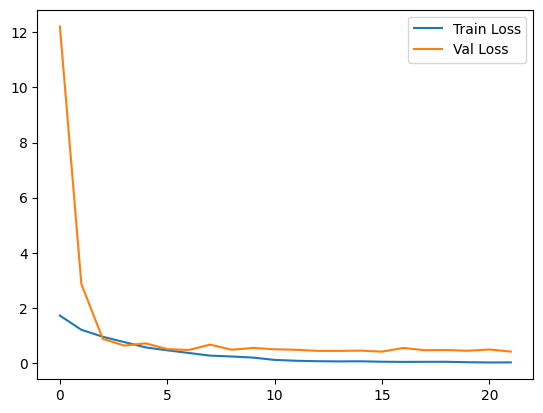

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()


In [20]:
import gradio as gr
import librosa
import numpy as np
genre_labels = [
    'blues', 'classical', 'country', 'disco', 'hiphop',
    'jazz', 'metal', 'pop', 'reggae', 'rock'
]


In [21]:
def preprocess_audio(file_path):
    audio, sr = librosa.load(
        file_path,
        sr=22050,
        duration=3   # SAME segment length
    )

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    mel_db = librosa.util.fix_length(
        mel_db,
        size=130,
        axis=1
    )

    # SAME normalization as training
    mel_db = mel_db.astype(np.float32)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-8)

    return mel_db[..., np.newaxis]


In [22]:
def predict_genre(audio_file):
    mel = preprocess_audio(audio_file)
    mel = np.expand_dims(mel, axis=0)

    preds = model.predict(mel)[0]
    result = {genre_labels[i]: float(preds[i]) for i in range(10)}

    return result


In [24]:
# Create folder
gradio_test_dir = "/content/gradio_test_audio"
os.makedirs(gradio_test_dir, exist_ok=True)

# Copy 2 test files per genre
limit = 2
count = {}

for path, label in zip(X_test_f, y_test_f):
    count[label] = count.get(label, 0)
    if count[label] < limit:
        shutil.copy(
            path,
            os.path.join(gradio_test_dir, f"{label}_{os.path.basename(path)}")
        )
        count[label] += 1

print("Copied files per genre:", count)
print("Folder created at:", gradio_test_dir)

Copied files per genre: {'disco': 2, 'pop': 2, 'rock': 2, 'metal': 2, 'jazz': 2, 'reggae': 2, 'classical': 2, 'hiphop': 2, 'blues': 2, 'country': 2}
Folder created at: /content/gradio_test_audio


In [23]:
interface = gr.Interface(
    fn=predict_genre,
    inputs=gr.Audio(type="filepath", label="Upload Music File"),
    outputs=gr.Label(num_top_classes=3),
    title="🎵 Music Genre Classification (GTZAN)",
    description="Upload a 3-second music clip to predict the genre"
)

interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://54e69aa33ebe3f827f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
